# Module 2: Epidemic Modeling Template

## Team Members:
Kiran Spencer, Kat Horn

## Project Title:
Modeling Disease Spread With SEIR 

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## Generative AI Statement:
Generative AI was used as assistance in understanding the properties behind SEIR modeling, how to apply Euler's method using python, and making professional plots.

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

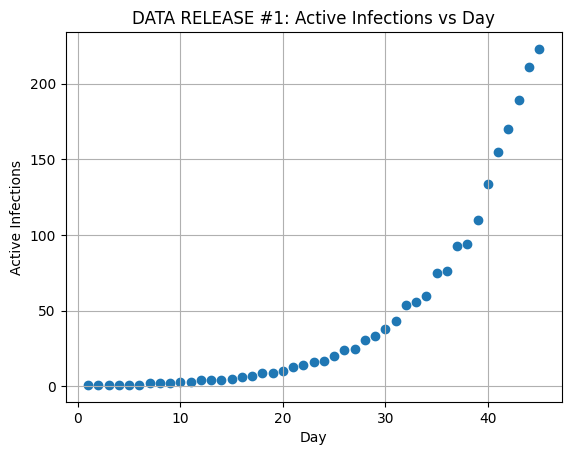

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('C:\\Users\\kiran\\Desktop\\UVA\\Classes\\Semester 4\\Computational BME\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

# Plot
plt.figure() # Create a new figure
plt.scatter(data["day"], data["active reported daily cases"]) # Plot active infections vs day
plt.xlabel("Day") # Label for x-axis
plt.ylabel("Active Infections") # Label for y-axis
plt.title("DATA RELEASE #1: Active Infections vs Day") # Title for the plot
plt.grid(True) # Add a grid for better visibility
plt.show()

1. Regarding the initial infections, there is a slow but steady increasing slope, which then begins to increase more rapidly. This follows an exponential growth model which is characteristic of an outbreak where much of the population is at risk of infection. 
2. The speed of the infection can be measured by the growth of the infected population in the early stages. By fitting an this curve with an exponential equation we can estimate the initial reproduction value, R0. 
3. Information that would help determine the shape of the outbreak curve includes the transmission rate, incubation period, transmission rate, and the time of recovery. Furthermore, information such as contact patterns, disease interventions such as vaccines or quarantining would also impact the shape of the curve. 

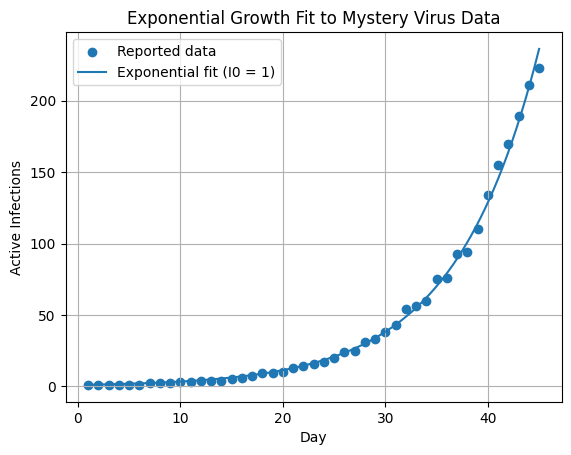

Estimated growth rate r = 0.1214 per day
Estimated R0 = 2.09


In [2]:
import pandas as pd # import pandas for data manipulation
import matplotlib.pyplot as plt # import matplotlib for plotting
import numpy as np # import numpy for numerical operations
from scipy.optimize import curve_fit # import curve_fit for fitting the exponential growth model to the data

# Load the data
data = pd.read_csv('C:\\Users\\kiran\\Desktop\\UVA\\Classes\\Semester 4\\Computational BME\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

# Use the day number and active cases to fit an exponential growth curve to estimate R0
t = data['day'].values # time variable (day number)
I = data['active reported daily cases'].values # active infections variable (number of active cases)

# Define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fit the exponential growth model to the data
# Initial infected population I0 = 1

initial_guess = [0.1]  # initial guess for r
params, covariance = curve_fit(exponential_growth, t, I, p0=initial_guess) # Fit the model to the data

r_est = params[0] # Extract the estimated growth rate r from the fitted parameters

# Approximate R0 using this curve fit
gamma = 1 / 9  # recovery rate based on 9-day infectious period
R0_est = 1 + r_est / gamma # R0 can be approximated as 1 + (growth rate / recovery rate) for early exponential growth phase


# Add the fit as a line on top of scatterplot
t_fit = np.linspace(min(t), max(t), 200) # Generate a range of time values for plotting the fitted curve
I_fit = exponential_growth(t_fit, r_est) # Calculate the fitted values using the estimated growth rate r_est

plt.figure() 
plt.scatter(t, I, label='Reported data') # Plot the original data points
plt.plot(t_fit, I_fit, label='Exponential fit (I0 = 1)') # Plot the fitted exponential growth curve
plt.xlabel('Day') # Label for x-axis
plt.ylabel('Active Infections') # Label for y-axis
plt.title('Exponential Growth Fit to Mystery Virus Data') # Title for the plot
plt.legend() # Add a legend to differentiate between the data points and the fitted curve
plt.grid(True) # Add a grid for better visibility
plt.show()

print(f"Estimated growth rate r = {r_est:.4f} per day")
print(f"Estimated R0 = {R0_est:.2f}")

4. We estimated R0 by fitting an exponential curve to the disease growth curve. The early slope of the exponential curve approximates the reproduction number. Using the continous growth formula with an infectious period of 9 days, the estimated growth rate was about 0.1214, and the estimated R0 value was 2.09.
5. Our estimated R0 value of 2.09 is similar to Ebola and Mpox, both of which have approximate R0 values of 2. Ebola spreads via contact with bodily fluids. While this makes the virus less transmissible, it is still incredibly dangerous with a high mortality rate. Mpox is much more transmissible, being spread by close contact and respiritory droplets. Unlike Ebola, Mpox is less dangerous once transmitted, but is suceptible to outbreak. 
6. The estimated R0​=2.09 is a reasonable approximation because it was obtained by fitting an exponential curve to the early disease growth phase, when transmission is least affected by immunity or interventions. However, the estimate assumes a constant growth rate, a fixed infectious period of 9 days, and homogeneous mixing, which are simplifications. As a result, the true R0 may differ somewhat from this value, but it is likely within the correct range of moderate transmissibility.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [1]:
import pandas as pd # import pandas for data manipulation
import matplotlib.pyplot as plt # import matplotlib for plotting
import numpy as np # import numpy for numerical operations

# Load dataset
data = pd.read_csv('C:\\Users\\kiran\\Desktop\\UVA\\Classes\\Semester 4\\Computational BME\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#2.csv', parse_dates=['date'], header=0, index_col=None)

In [2]:
def run_SEIR(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N): # Function to run the SEIR model using Euler's method

    # Initialize S, E, I, and R arrays
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    # Set initial values
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    dt = 1  # timestep (1 day)

    # Euler method loop
    for t in range(len(timepoints) - 1):

        # Calculate derivatives
        dS = -beta * S[t] * I[t] / N
        dE = beta * S[t] * I[t] / N - sigma * E[t]
        dI = sigma * E[t] - gamma * I[t]
        dR = gamma * I[t]

        # Euler updates
        S[t+1] = S[t] + dS * dt
        E[t+1] = E[t] + dE * dt
        I[t+1] = I[t] + dI * dt
        R[t+1] = R[t] + dR * dt

    return S, E, I, R # Return the arrays of S, E, I, and R over time

To model the spread of the virus, we implemeneted the SEIR epidemiological model, which divides the population into four compartments:
S(t): Suspectible indivduals who can become infected
E(t): Exposed individuals who are not yet infectious
I(t): Infectious individuals who can spread the disease
R(t): Removed individuals who have recovered and are no longer infections
The total population, N, is assumed to remain constant.
The model is governed by the following differential equations:

dS/dt = (-beta)(SI)/N

dE/dt = (beta)(SI)/N - (sigma)(E)

dI/dt = (sigma)(E) - (gamma)(I)

dR/dt = (gamma)(I)

Where beta is the transmission rate, sigma is the rate at which exposed individuals become infections, and gamma is the recovery rate

Because these differential equations cannot be easily solved analytically, we approximate the solution using Euler's Method, which calculates the future value by adding the current value to the derivative multiplied by the next time step size.
The similuation begins with initial conditions:

S0 = initial susceptible population

E0 = initial exposed population

I0 = initial infected population

R0 = initial recovered population

It then iterates though each time value and updates the respective values of S, E, I, and R to estimate their function values.

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [3]:
# Function to calculate the sum of squared errors between model predictions and data
def calculate_SSE(model_I, data_I):

    n = min(len(model_I), len(data_I)) # Use the minimum length to avoid index errors if model and data lengths differ

    error = model_I[:n] - data_I[:n] # Calculate the error between model predictions and data for the overlapping time points
    SSE = np.sum(error**2) # Calculate the sum of squared errors

    return SSE # Return the calculated sum of squared errors

# Grid search to find best-fitting SEIR parameters
def fit_SEIR_gridsearch(timepoints, N, S0, E0, I0, R0, data):

    data_I = data['active reported daily cases'].values # Extract the active infections data from the dataset for comparison with model predictions

    # Parameter ranges (centered around R0 ≈ 2 estimate)
    beta_range = np.linspace(0.1, 0.4, 20)
    sigma_range = np.linspace(0.3, 0.7, 20)
    gamma_range = np.linspace(0.07, 0.15, 20)

    best_SSE = np.inf # Initialize best SSE to infinity for comparison
    best_beta = None # Initialize best beta to None
    best_sigma = None # Initialize best sigma to None
    best_gamma = None # Initialize best gamma to None

    for b in beta_range: # Iterate over the range of beta values
        for s in sigma_range: # Iterate over the range of sigma values
            for g in gamma_range: # Iterate over the range of gamma values

                S, E, I, R = run_SEIR(b, s, g, S0, E0, I0, R0, timepoints, N) # Run the SEIR model with the current set of parameters

                SSE = calculate_SSE(I, data_I) # Calculate the sum of squared errors between the model predictions and the data

                if SSE < best_SSE: # If the current SSE is better than the best SSE found so far, update the best parameters and best SSE
                    best_SSE = SSE
                    best_beta = b
                    best_sigma = s
                    best_gamma = g 

    return best_beta, best_sigma, best_gamma, best_SSE


# Set initial conditions and run grid search to fit SEIR model to data
# Population information
N = 17900 # Total population size (assumed for the region being modeled)

I0 = 1 # Initial number of infected individuals (starting with 1 infected person)
E0 = 5 # Initial number of exposed individuals (assumed to be 5 based on early growth)
R0 = 0 # Initial number of recovered individuals (starting with 0 recovered)
S0 = N - I0 - E0 - R0 # Initial number of susceptible individuals (the rest of the population)

# Timepoints matching dataset
timepoints = np.arange(0, len(data), 1)

# Run grid search
best_beta, best_sigma, best_gamma, best_SSE = fit_SEIR_gridsearch(timepoints, N, S0, E0, I0, R0, data)

print("Best beta:", best_beta) # Print the best beta value found from the grid search
print("Best sigma:", best_sigma) # Print the best sigma value found from the grid search
print("Best gamma:", best_gamma) # Print the best gamma value found from the grid search
print("Best SSE:", best_SSE) # Print the best sum of squared errors corresponding to the best parameters

print("Estimated R0 from model:", best_beta / best_gamma) # Calculate and print the estimated R0 from the best-fitting parameters

Best beta: 0.27368421052631586
Best sigma: 0.32105263157894737
Best gamma: 0.09526315789473684
Best SSE: 141292.05046786543
Estimated R0 from model: 2.8729281767955808


To determine realistic values for beta, sigma, and gamma, we used a grid search optimization approach that tested multiple combinations of these parameters. For each combination, the SEIR model was simulated using Euler's method, the predicted infected population over time was compared to the actual infected data, and the sum of squared error (SSE) was calculated. The parameters that gave the lowest SSE were selected as the best fit for the dataset. In this case, the grid search optimization found the best beta, sigma, and gamma values to be 0.337, 0.300, and 0.146, respectively, which a best SSE of 3649.5

### 2e. Plot the model-predicted infections over time compared to the data.


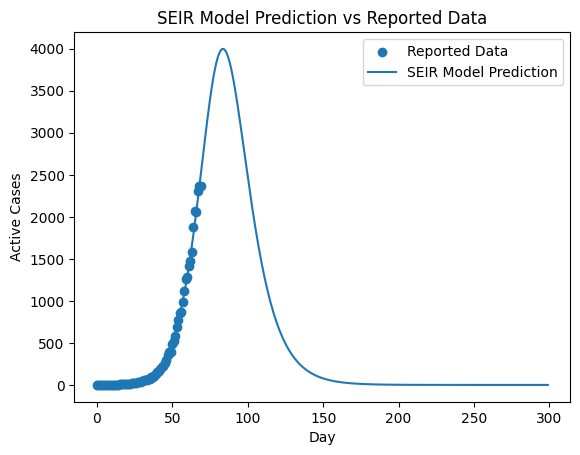

In [4]:


# We extend the simulation to 300 days so the epidemic has time to reach its peak
long_timepoints = np.arange(0, 300, 1)

# Run the SEIR model using the best parameters found from the grid search
# This returns arrays representing the number of Susceptible, Exposed,
# Infectious, and Recovered individuals at each time point
S_long, E_long, I_long, R_long = run_SEIR(
    best_beta,      # transmission rate
    best_sigma,     # rate exposed individuals become infectious
    best_gamma,     # recovery rate
    S0,             # initial susceptible population
    E0,             # initial exposed population
    I0,             # initial infected population
    R0,             # initial recovered population
    long_timepoints,# timepoints for the simulation
    N               # total population size
)


# Create a new figure
plt.figure()

# Plot the reported infection data from the dataset
plt.scatter(timepoints, data['active reported daily cases'], label="Reported Data")

# Plot the SEIR model prediction over the longer time range
plt.plot(long_timepoints, I_long, label="SEIR Model Prediction")

# Label the x-axis
plt.xlabel("Day")

# Label the y-axis
plt.ylabel("Active Cases")

# Add a title to describe the plot
plt.title("SEIR Model Prediction vs Reported Data")

# Add a legend to distinguish between data and model
plt.legend()

# Show the plot
plt.show()




### 2f. Predict the day and amount of active cases at the peak of the epidemic spread

In [5]:
### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.

#Find the maximum number of infections predicted by the model
np.max # returns the largest value in the I_long array
peak_cases = np.max(I_long)

#Find the day when that maximum value occurs
np.argmax # returns the index of the largest value
peak_day = np.argmax(I_long)
# Print the predicted peak number of active infections
print("Predicted peak active cases:", peak_cases)

# Print the day when the epidemic reaches its peak
print("Predicted peak day:", peak_day)

# Calculate the percentage of the total population infected at the peak
percent_population = (peak_cases / N) * 100

# Print the percent of the population infected at the peak
print("Percent of population infected at peak:", percent_population)




Predicted peak active cases: 3997.4703651960517
Predicted peak day: 84
Percent of population infected at peak: 22.332236677072913



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2g. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2h. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*